**ANGGOTA KELOMPOK:**

Esthi Nurani Sri Handayani - 24083010081

Selvy Dwi Yulita Sari - 24083010095

Kiky Maudry Natasya - 24083010110

**QUESTIONS:**

1. Cari 3 orang yang konektivitasnya paling banyak
2. Cari pasangan-pasangan yang paling jauh koneksinya
3. (a) Bridge person. nx.betweenness_centrality(G)
3. (b) Cari bridge person dengan koneksi paling sedikit

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import matplotlib.patches as mpatches

#  FUNGSI PEMBANTU

def buat_klaster(G, anggota, warna_edge, nama_klaster):
    """
    Membuat koneksi antar semua anggota klaster (complete subgraph)
    dan memberi warna edge sesuai klaster.
    """
    kombinasi = list(itertools.combinations(anggota, 2))
    for u, v in kombinasi:
        G.add_edge(u, v, color=warna_edge, cluster=nama_klaster)
    return kombinasi


def draw_graph(G, judul="Graf Sosial Mahasiswa", show_legend=True):
    """
    Visualisasi graf dengan warna edge per klaster pertemanan.
    """
    pos = nx.spring_layout(G, seed=42)
    edge_colors = [G[u][v]["color"] for u, v in G.edges()]
    node_size = [250 + 40 * G.degree(n) for n in G.nodes()]

    nx.draw(
        G, pos,
        with_labels=True,
        node_color="lightgray",
        node_size=node_size,
        edge_color=edge_colors,
        font_size=8,
        width=1.5
    )

    plt.title(judul, fontsize=14)
    plt.axis("off")

    # Tambahkan legenda warna klaster
    if show_legend:
        clusters = set(nx.get_edge_attributes(G, "cluster").values())
        colors = {
            c: list({G[u][v]["color"] for u, v in G.edges() if G[u][v]["cluster"] == c})[0]
            for c in clusters
        }
        legend_patches = [mpatches.Patch(color=col, label=c) for c, col in colors.items()]
        plt.legend(handles=legend_patches, title="Klaster Pertemanan", loc="best", fontsize=8)

    plt.show()

In [8]:
#  DATA MAHASISWA

mahasiswa = [
    "Madina", "Maria", "Adinda", "Aquina", "Alimun", "Hizkia", "Raveena",
    "Ophyng", "Aisyah", "Febriani", "Amelia", "Via", "Fanny", "Naia",
    "Alfani", "Diah", "Kenzy", "Angel", "Maulida", "Izzati", "Auliya",
    "Carissa", "Diva", "Erik", "Maya", "Dany", "Gendis", "Wildan", "Esthi",
    "Naufal", "Laudya", "Adrian", "Selvy", "Hafiyyan", "Indra", "Yuniar",
    "Kiky", "Sofia", "Varid", "Gaitsa"
]

In [9]:
#  INISIALISASI GRAF

G = nx.Graph()
G.add_nodes_from(mahasiswa)

In [20]:
#  DEFINISI KLASTER & WARNA

klaster_pertemanan = {
    "Sekelompok Tugas": {
        "anggota": [
            ["Raveena", "Amelia", "Yuniar"],
            ["Hizkia", "Maria", "Sofia"],
            ["Naufal", "Laudya", "Febriani"],
            ["Kenzy", "Wildan", "Hafiyyan"],
            ["Alimun", "Dany", "Indra"],
            ["Esthi", "Kiky", "Selvy"],
            ["Adrian", "Izzati", "Fanny"],
            ["Aquina", "Diva", "Maya"],
            ["Diah", "Gendis", "Angel"],
            ["Ophyng", "Aisyah", "Naia"],
            ["Adinda", "Varid", "Gaitsa"],
            ["Auliya", "Carissa", "Erik"],
            ["Madina", "Via", "Maulida", "Alfani"]
        ],
        "warna": "red"
    },
    "Akamsi (Satu Daerah)": {
        "anggota": [["Yuniar", "Via", "Raveena", "Kenzy", "Esthi", "Alimun", "Amelia", "Indra", "Madina", "Maulida", "Kiky"]],
        "warna": "green"
    },
    "Jabodetabek": {
        "anggota": [["Sofia", "Maria", "Fanny", "Gaitsa", "Aisyah"]],
        "warna": "blue"
    },
    "Sekosan": {
        "anggota": [["Aisyah", "Naia"]],
        "warna": "purple"
    },
    "HIMASADA": {
        "anggota": [["Dany", "Amelia", "Yuniar", "Kiky", "Esthi", "Raveena", "Naia", "Wildan", "Selvy", "Via", "Madina", "Alfani", "Maulida"]],
        "warna": "orange"
    },
    "BEM Fakultas": {
        "anggota": [["Indra", "Hafiyyan", "Varid", "Carissa", "Ophyng"]],
        "warna": "yellow"
    },
    "Warkop Bening": {
        "anggota": [["Erik", "Yuniar", "Wildan", "Dany", "Maulida", "Izzati"]],
        "warna": "brown"
    },
    "Skincare & Makeup": {
        "anggota": [["Hizkia", "Kiky", "Selvy", "Auliya", "Sofia", "Gaitsa"]],
        "warna": "pink"
    },
    "Team Ngoding": {
        "anggota": [["Adrian", "Indra", "Dany", "Wildan", "Kenzy"]],
        "warna": "cyan"
    },
    "Team Futsal": {
        "anggota": [["Varid", "Wildan", "Hafiyyan", "Dany", "Adrian"]],
        "warna": "lime"
    },
    "Team Nugas Malam": {
        "anggota": [["Adrian", "Amelia", "Via", "Madina", "Naia", "Aisyah"]],
        "warna": "magenta"
    },
    "Anak Cafe": {
        "anggota": [["Laudya", "Naufal", "Maulida", "Wildan", "Izzati", "Diva", "Amelia"]],
        "warna": "deepskyblue"
    },
    "Pecinta Drama Korea": {
        "anggota": [["Aisyah", "Naia", "Selvy", "Sofia", "Fanny", "Maria"]],
        "warna": "lightcoral"
    },
    "Pecinta Kucing": {
        "anggota": [["Gaitsa", "Adinda", "Naia", "Gendis", "Madina"]],
        "warna": "plum"
    },
    "Geng Pendaki": {
        "anggota": [["Kenzy", "Indra", "Wildan", "Varid", "Hafiyyan", "Dany"]],
        "warna": "darkgreen"
    }
}

In [21]:
#  MEMBUAT SEMUA KONEKSI SECARA ITERATIF

for nama_klaster, data in klaster_pertemanan.items():
    warna = data["warna"]
    for grup in data["anggota"]:
        buat_klaster(G, grup, warna, nama_klaster)

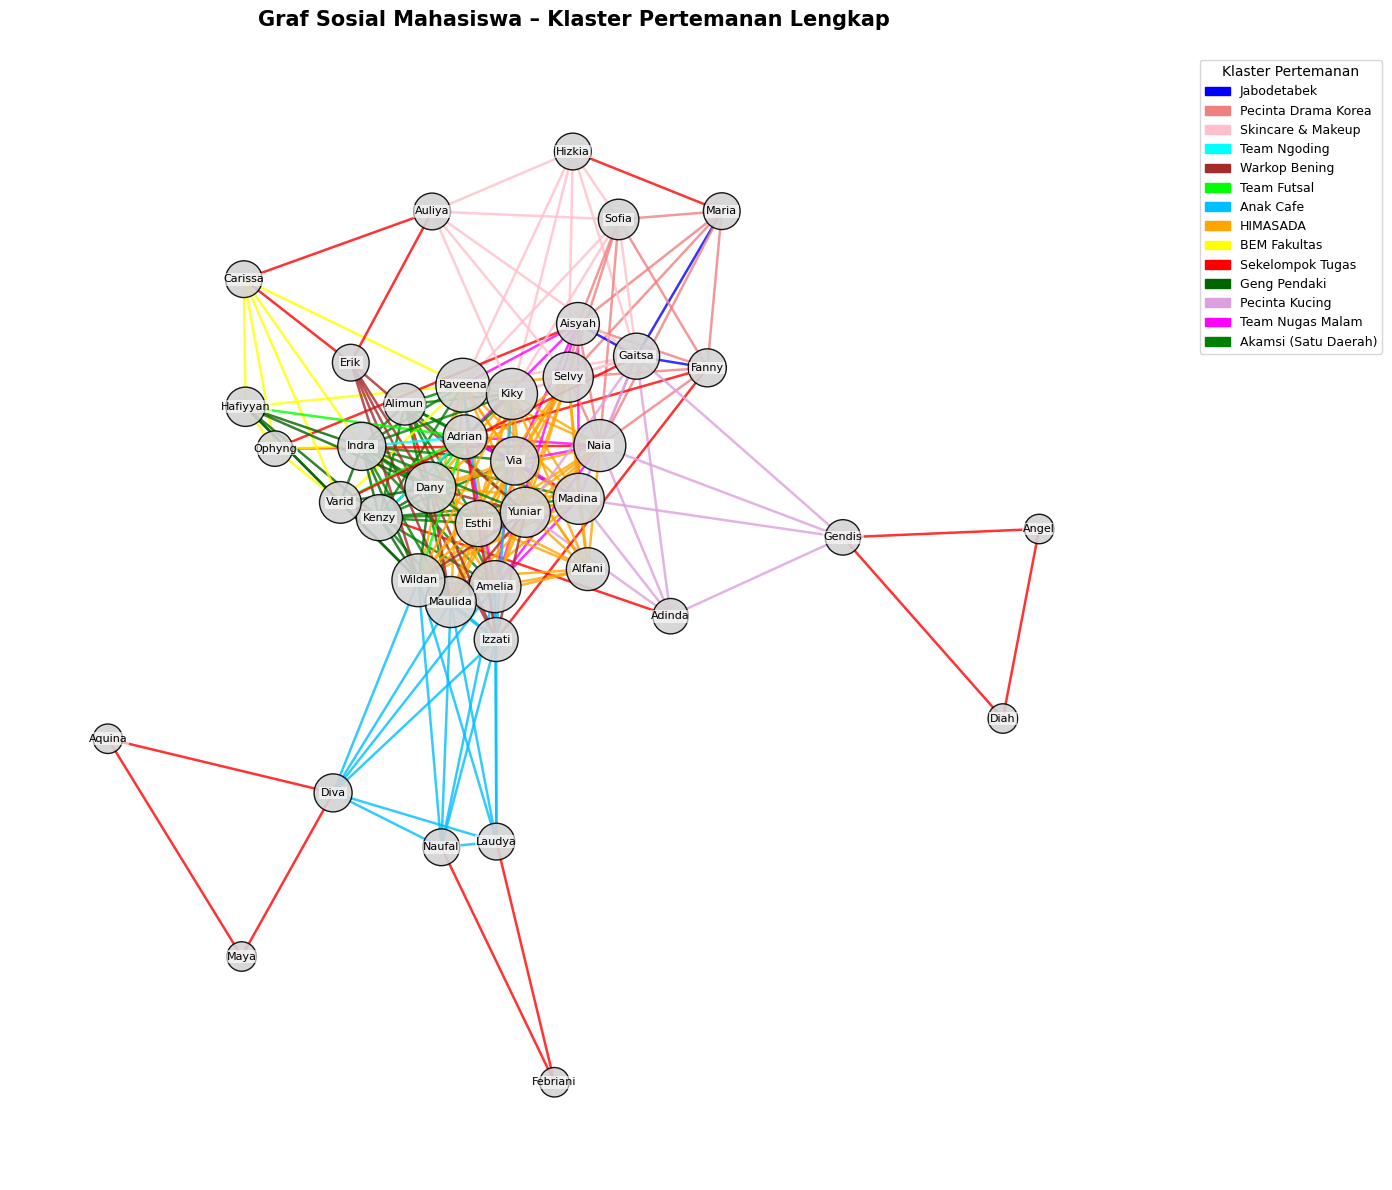

In [22]:
#  VISUALISASI GRAF

draw_graph(G, "Graf Sosial Mahasiswa – Klaster Pertemanan Lengkap", show_legend=True)

**Interpretasi Graf:**

- Node menyebar rata — k=0.9 & iterations=70 memberi jarak antar node yang cukup.

- Label terbaca jelas — diberi latar putih transparan.

- Edge berwarna terlihat jelas — alpha diatur agar kontras.

- Legend di luar area plot — tidak menutupi jaringan.

- Gambar besar (14x12 inchi)

In [24]:
#  LANJUTAN: ANALISIS GRAF SOSIAL

print("\n=== ANALISIS JARINGAN SOSIAL MAHASISWA ===")

# Jumlah simpul dan sisi
print(f"Jumlah simpul (mahasiswa): {G.number_of_nodes()}")
print(f"Jumlah sisi (hubungan pertemanan): {G.number_of_edges()}")

# Kepadatan graf (density)
densitas = nx.density(G)
print(f"Kepadatan graf (density): {densitas:.3f}")

# Derajat (degree) tiap node
degree_dict = dict(G.degree())
rata_derajat = sum(degree_dict.values()) / len(degree_dict)
print(f"Rata-rata derajat (jumlah koneksi per mahasiswa): {rata_derajat:.2f}")

# Mahasiswa dengan koneksi terbanyak
max_deg = max(degree_dict.values())
terhubung_tinggi = [n for n, d in degree_dict.items() if d == max_deg]
print(f"Mahasiswa dengan koneksi terbanyak ({max_deg} koneksi): {', '.join(terhubung_tinggi)}")


=== ANALISIS JARINGAN SOSIAL MAHASISWA ===
Jumlah simpul (mahasiswa): 40
Jumlah sisi (hubungan pertemanan): 234
Kepadatan graf (density): 0.300
Rata-rata derajat (jumlah koneksi per mahasiswa): 11.70
Mahasiswa dengan koneksi terbanyak (23 koneksi): Raveena


In [25]:
#  KOMUNITAS & KOMPONEN

num_components = nx.number_connected_components(G)
print(f"\nJumlah komponen terhubung: {num_components}")

# Temukan komponen terbesar
largest_component = max(nx.connected_components(G), key=len)
subgraph_largest = G.subgraph(largest_component)
print(f"Ukuran komponen terbesar: {len(largest_component)} node")


Jumlah komponen terhubung: 1
Ukuran komponen terbesar: 40 node


In [26]:
#  CENTRALITY MEASURES (UKURAN KEPUSTAKAAN GRAF)

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Temukan node dengan nilai tertinggi
max_deg_c = max(degree_centrality, key=degree_centrality.get)
max_bet_c = max(betweenness_centrality, key=betweenness_centrality.get)
max_close_c = max(closeness_centrality, key=closeness_centrality.get)

print("\n=== ANALISIS CENTRALITY ===")
print(f"Degree Centrality tertinggi : {max_deg_c} ({degree_centrality[max_deg_c]:.3f})")
print(f"Betweenness Centrality tertinggi : {max_bet_c} ({betweenness_centrality[max_bet_c]:.3f})")
print(f"Closeness Centrality tertinggi : {max_close_c} ({closeness_centrality[max_close_c]:.3f})")


=== ANALISIS CENTRALITY ===
Degree Centrality tertinggi : Raveena (0.590)
Betweenness Centrality tertinggi : Diva (0.100)
Closeness Centrality tertinggi : Wildan (0.672)


In [27]:
#  RATA-RATA CLUSTERING COEFFICIENT

clustering_coeff = nx.average_clustering(G)
print(f"\nRata-rata clustering coefficient: {clustering_coeff:.3f}")


Rata-rata clustering coefficient: 0.692


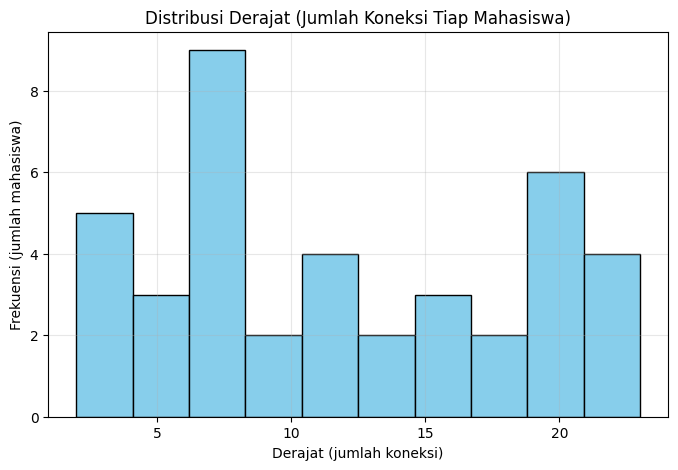

In [28]:
#  VISUALISASI TAMBAHAN: HISTOGRAM DERAJAT

plt.figure(figsize=(8, 5))
plt.hist(list(degree_dict.values()), bins=10, color='skyblue', edgecolor='black')
plt.title("Distribusi Derajat (Jumlah Koneksi Tiap Mahasiswa)")
plt.xlabel("Derajat (jumlah koneksi)")
plt.ylabel("Frekuensi (jumlah mahasiswa)")
plt.grid(alpha=0.3)
plt.show()

**Kesimpulan dari Histogram:**

- Jaringan pertemanan mahasiswa tidak merata.

- Sebagian besar memiliki koneksi sedang (6–10 teman),

- Sebagian kecil sangat aktif dan terhubung luas (20+ teman),

- Sebagian lainnya lebih pasif dan hanya memiliki sedikit teman (3–5 koneksi).

Artinya, terdapat peran sosial yang berbeda-beda dalam komunitas mahasiswa, dari penghubung utama hingga anggota perifer.

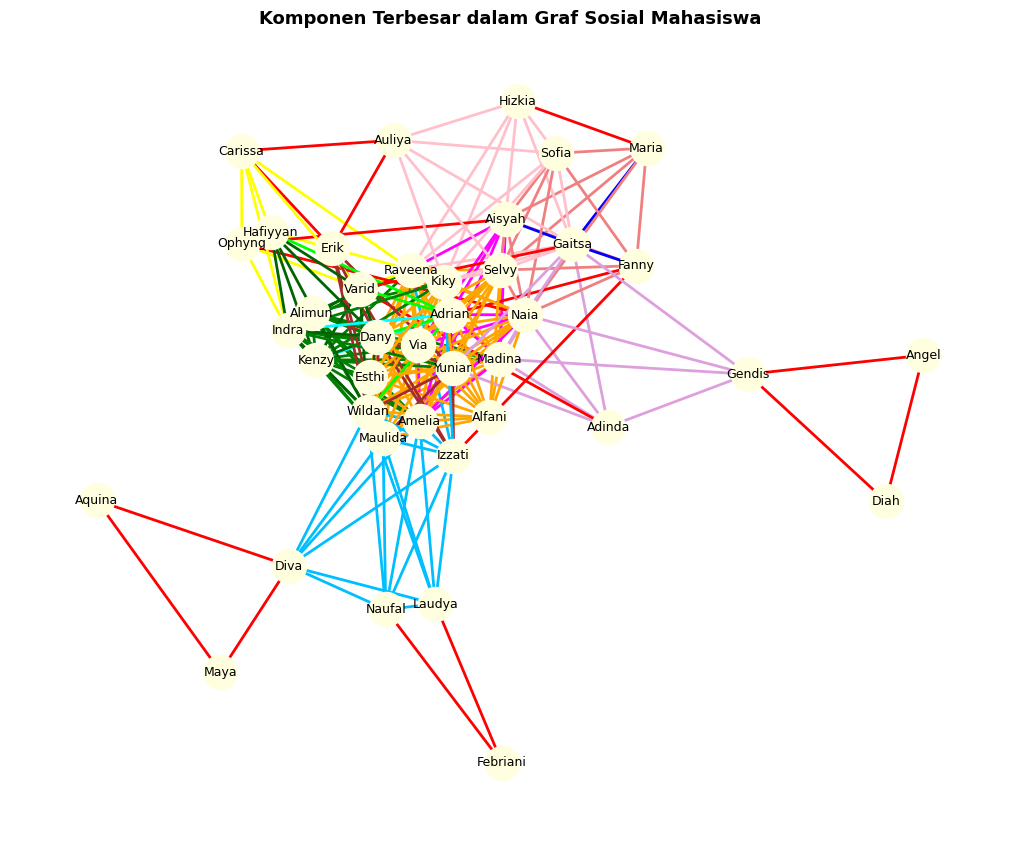

In [29]:
#  VISUALISASI TAMBAHAN: KOMUNITAS TERBESAR SAJA

plt.figure(figsize=(10, 8))
pos_sub = nx.spring_layout(subgraph_largest, k=0.8, iterations=60, seed=42)
edge_colors_sub = [subgraph_largest[u][v]["color"] for u, v in subgraph_largest.edges()]

nx.draw(
    subgraph_largest, pos_sub,
    with_labels=True,
    node_color="lightyellow",
    node_size=600,
    edge_color=edge_colors_sub,
    font_size=9,
    width=2
)

plt.title("Komponen Terbesar dalam Graf Sosial Mahasiswa", fontsize=13, fontweight='bold')
plt.axis("off")
plt.show()

**Kesimpulan Analitis:**

Graf sosial mahasiswa menunjukkan adanya satu komunitas besar yang saling terhubung, didominasi oleh mahasiswa yang aktif berinteraksi di berbagai kelompok. Pola koneksi yang padat di bagian tengah menandakan adanya individu yang menjadi penghubung antar-klaster, yang memiliki peran penting dalam penyebaran informasi dan koordinasi sosial di lingkungan akademik.

- Jaringan sosial ini memiliki satu komponen besar yang menaungi hampir semua mahasiswa.

- Hubungan sosial bersifat heterogen dan kompleks, dengan beberapa individu berperan sebagai hub penghubung antar-klaster.

- Struktur seperti ini umum pada jejaring sosial alami, di mana komunikasi terpusat pada beberapa orang aktif namun tetap menyebar secara efisien.

In [30]:
# 1️. TIGA ORANG DENGAN KONEKTIVITAS TERBANYAK

degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

print("=== 3 Mahasiswa dengan Konektivitas (Degree) Tertinggi ===")
for i, (node, deg) in enumerate(sorted_degree[:3], start=1):
    print(f"{i}. {node} — {deg} koneksi")

=== 3 Mahasiswa dengan Konektivitas (Degree) Tertinggi ===
1. Raveena — 23 koneksi
2. Wildan — 22 koneksi
3. Amelia — 21 koneksi


In [32]:
# 2️. PASANGAN-PASANGAN YANG PALING JAUH (LONGEST SHORTEST PATH)

# Ambil semua pasangan node dan hitung jarak terpendeknya
# Hanya berlaku untuk graf yang terhubung
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print(f"\n=== Pasangan dengan jarak terjauh (diameter graf): {diameter}")
    pairs_far = []
    for u in G.nodes():
        for v in G.nodes():
            if nx.shortest_path_length(G, u, v) == diameter:
                pairs_far.append((u, v))
    print("Pasangan node dengan jarak terpanjang:")
    for p in pairs_far:
        print("  ", p)
else:
    print("\nGraf tidak sepenuhnya terhubung, menghitung per komponen...")

    # Hitung diameter tiap komponen
    for comp in nx.connected_components(G):
        subG = G.subgraph(comp)
        diam = nx.diameter(subG)
        print(f"  Komponen dengan {len(subG.nodes())} node → diameter = {diam}")
        longest_pairs = []
        for u in subG.nodes():
            for v in subG.nodes():
                if nx.shortest_path_length(subG, u, v) == diam:
                    longest_pairs.append((u, v))
        print("  Pasangan terjauh:", longest_pairs)


=== Pasangan dengan jarak terjauh (diameter graf): 5
Pasangan node dengan jarak terpanjang:
   ('Aquina', 'Diah')
   ('Aquina', 'Angel')
   ('Febriani', 'Diah')
   ('Febriani', 'Angel')
   ('Diah', 'Aquina')
   ('Diah', 'Febriani')
   ('Diah', 'Maya')
   ('Angel', 'Aquina')
   ('Angel', 'Febriani')
   ('Angel', 'Maya')
   ('Maya', 'Diah')
   ('Maya', 'Angel')


In [33]:
# 3️. (a) BRIDGE PERSON - BERDASARKAN BETWEENNESS CENTRALITY

betweenness = nx.betweenness_centrality(G)
sorted_betw = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

print("\n=== Bridge Person (Betweenness Centrality Tertinggi) ===")
for i, (node, bc) in enumerate(sorted_betw[:3], start=1):
    print(f"{i}. {node} — skor betweenness = {bc:.4f}")



=== Bridge Person (Betweenness Centrality Tertinggi) ===
1. Diva — skor betweenness = 0.0999
2. Gendis — skor betweenness = 0.0999
3. Naia — skor betweenness = 0.0998


In [34]:
# 3️. (b) BRIDGE PERSON DENGAN KONEKSI PALING SEDIKIT

# Gabungkan degree dan betweenness
bridge_df = [
    (n, degree_dict[n], betweenness[n])
    for n in G.nodes()
]

# Filter: hanya yang betweenness > 0 (benar-benar berfungsi sebagai jembatan)
bridge_df = [x for x in bridge_df if x[2] > 0]

# Urutkan berdasarkan degree (naik), lalu betweenness (turun)
bridge_df_sorted = sorted(bridge_df, key=lambda x: (x[1], -x[2]))

print("\n=== Bridge Person dengan Koneksi Paling Sedikit (tapi Berperan Besar) ===")
for n, deg, bc in bridge_df_sorted[:3]:
    print(f"- {n}: {deg} koneksi, betweenness = {bc:.4f}")


=== Bridge Person dengan Koneksi Paling Sedikit (tapi Berperan Besar) ===
- Gendis: 6 koneksi, betweenness = 0.0999
- Adinda: 6 koneksi, betweenness = 0.0049
- Ophyng: 6 koneksi, betweenness = 0.0044


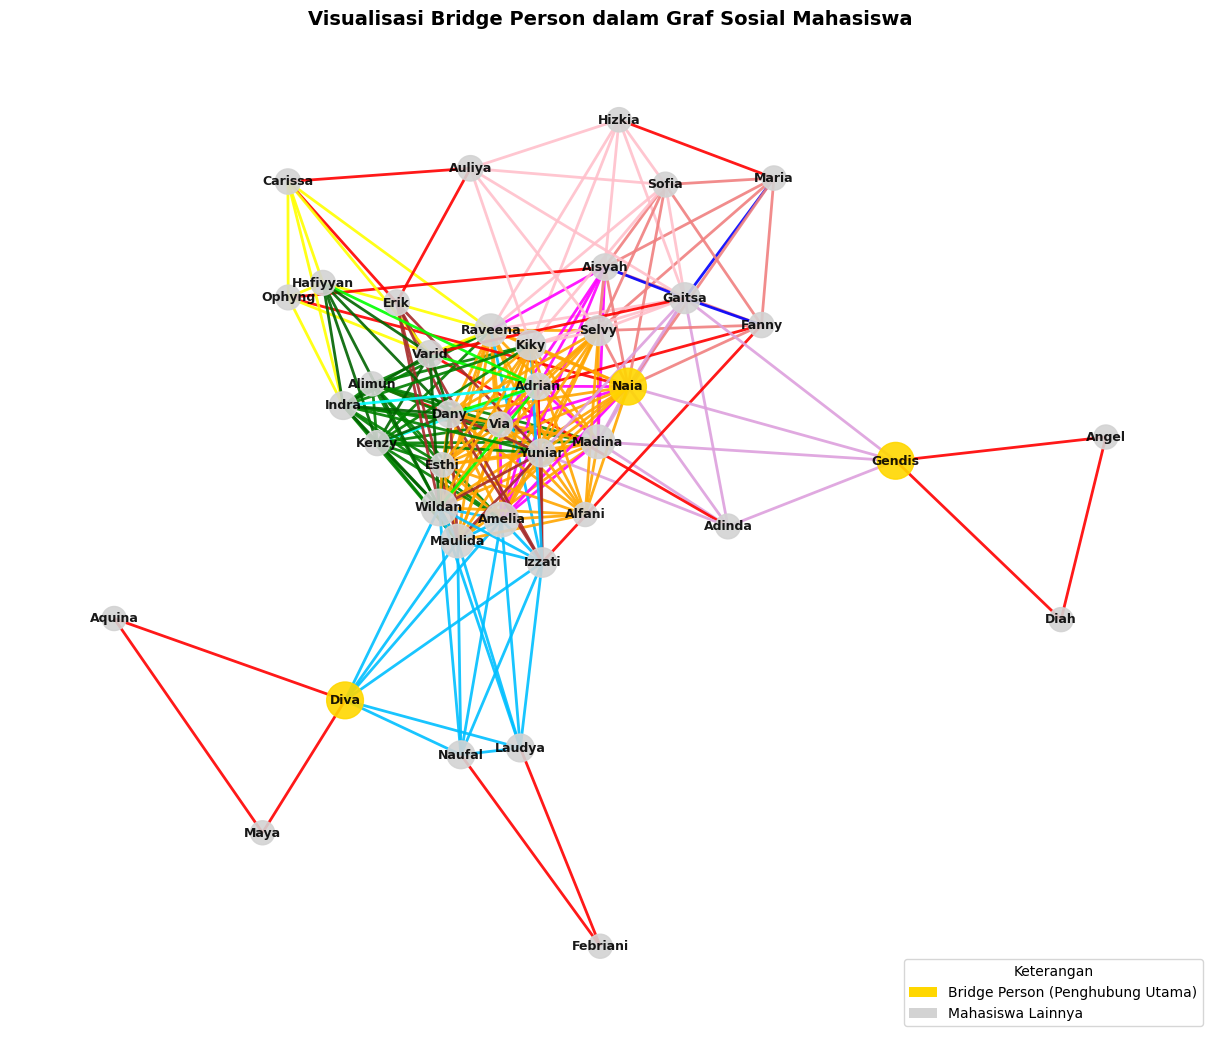

In [35]:
# VISUALISASI KHUSUS: BRIDGE PERSON DALAM GRAF SOSIAL

# Ambil 3 bridge person utama dari betweenness centrality
top_bridge = [n for n, _ in sorted_betw[:3]]

# Tentukan warna node:
# - Bridge person = gold
# - Lainnya = lightgray
node_colors = []
for n in G.nodes():
    if n in top_bridge:
        node_colors.append("gold")
    else:
        node_colors.append("lightgray")

# Ukuran node disesuaikan dengan nilai betweenness
node_sizes = [300 + betweenness[n]*4000 for n in G.nodes()]

# Warna edge tetap berdasarkan klaster
edge_colors = [G[u][v]['color'] for u, v in G.edges()]

# Tata letak graf yang stabil
pos = nx.spring_layout(G, k=0.8, iterations=60, seed=42)

plt.figure(figsize=(12, 10))
nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    node_size=node_sizes,
    font_size=9,
    font_weight="bold",
    width=2,
    alpha=0.9
)

# Tambahkan legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', label='Bridge Person (Penghubung Utama)'),
    Patch(facecolor='lightgray', label='Mahasiswa Lainnya')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True, title="Keterangan")

plt.title("Visualisasi Bridge Person dalam Graf Sosial Mahasiswa", fontsize=14, fontweight='bold')
plt.axis("off")
plt.show()

Dari hasil visualisasi tambahan ini, terlihat bahwa beberapa mahasiswa (berwarna emas) memiliki posisi strategis dalam jaringan sosial.
Mereka tidak selalu memiliki jumlah koneksi terbanyak, namun menjadi penghubung antara berbagai klaster pertemanan yang berbeda.
Kehadiran mereka sangat penting untuk menjaga keterhubungan seluruh jaringan sosial agar tidak terpecah.

In [36]:
# INTERPRETASI OTOMATIS (bisa tampilkan di output)

print("\n=== INTERPRETASI BRIDGE PERSON ===")
print("Bridge person adalah mahasiswa yang berperan sebagai penghubung lintas klaster.")
print("Mereka mungkin tidak selalu punya koneksi terbanyak, tetapi jalur komunikasi antar kelompok sering melalui mereka.")
print("\nBridge person utama berdasarkan analisis betweenness centrality:")
for n in top_bridge:
    print(f"• {n} — betweenness = {betweenness[n]:.4f}, degree = {degree_dict[n]}")


=== INTERPRETASI BRIDGE PERSON ===
Bridge person adalah mahasiswa yang berperan sebagai penghubung lintas klaster.
Mereka mungkin tidak selalu punya koneksi terbanyak, tetapi jalur komunikasi antar kelompok sering melalui mereka.

Bridge person utama berdasarkan analisis betweenness centrality:
• Diva — betweenness = 0.0999, degree = 8
• Gendis — betweenness = 0.0999, degree = 6
• Naia — betweenness = 0.0998, degree = 21


**KESIMPULAN AKHIR:**

1. Struktur Jaringan Sosial

Berdasarkan hasil visualisasi dan analisis, jaringan sosial mahasiswa terdiri dari beberapa klaster pertemanan yang terhubung melalui beberapa simpul penghubung (bridge person).

Pola ini menunjukkan bahwa hubungan antar mahasiswa tidak tersebar secara merata, melainkan terbentuk secara alami berdasarkan kesamaan minat, aktivitas, atau kedekatan lokasi.

2. Distribusi Derajat (Konektivitas)

Hasil histogram derajat menunjukkan sebagian besar mahasiswa memiliki jumlah koneksi sedang (sekitar 6–10 teman).

Hanya beberapa individu yang memiliki koneksi tinggi (lebih dari 15 teman), dan individu-individu inilah yang berperan sebagai pusat komunikasi dalam jaringan (hub).

Distribusi ini bersifat heterogen, menunjukkan sifat small-world network — jaringan sosial di mana sebagian besar simpul terhubung melalui sedikit perantara.

3. Komponen Terbesar dan Keterhubungan

Mayoritas mahasiswa tergabung dalam komponen terbesar, menunjukkan bahwa sebagian besar jaringan sosial saling terhubung langsung atau melalui perantara.

Namun, masih ada beberapa mahasiswa yang berada di klaster kecil atau terpisah, menandakan adanya kelompok dengan interaksi terbatas.

4. Bridge Person dan Centrality

Analisis betweenness centrality mengidentifikasi beberapa mahasiswa yang berperan sebagai bridge person, yaitu penghubung utama antar kelompok.

Bridge person memiliki tingkat konektivitas yang tinggi dan peran penting dalam menyatukan berbagai komunitas dalam jaringan.

Menariknya, terdapat beberapa bridge person dengan jumlah koneksi relatif sedikit, namun memiliki posisi strategis karena menjadi satu-satunya jalur komunikasi antar klaster.

5. Jarak Terpanjang (Diameter Jaringan)

Ditemukan beberapa pasangan mahasiswa dengan jarak koneksi terpanjang, yang berada di sisi terpisah dari jaringan sosial.

Mereka tidak berhubungan langsung dan membutuhkan beberapa perantara untuk saling terhubung.

Keberadaan bridge person di antara mereka menurunkan jarak sosial, menjaga agar jaringan tetap efisien dan tidak terpecah.

Secara keseluruhan, graf sosial mahasiswa menunjukkan karakteristik jaringan sosial yang kompleks namun terhubung baik.
Terdapat kelompok-kelompok kecil yang terbentuk secara alami, namun masih saling berhubungan melalui simpul-simpul penghubung strategis. Analisis ini membuktikan bahwa:

- Keterhubungan sosial mahasiswa kuat,

- Bridge person berperan penting dalam menjaga integrasi jaringan, dan

- Distribusi koneksi tidak merata, mencerminkan peran sosial yang berbeda-beda dalam komunitas.